In [6]:
pip install matplotlib

  Using cached matplotlib-3.10.7-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.0-cp314-cp314-win_amd64.whl.metadata (115 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.0.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.7-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.0-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.0.0-cp314-cp314-win_amd64.whl (7.1 MB)
Using cached pyparsing-3.2.5-py3-none-any.whl (113 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -

In [9]:
import json
import sys
import time
import os
from tqdm import tqdm
from openai import OpenAI
from dotenv import load_dotenv


from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage


# Load environment variables from current directory .env and override existing ones
load_dotenv(".env", override=True)

# load api key from environment
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY not found in .env file")

client = OpenAI(api_key=api_key)

In [22]:
# function for getting embeddings from API
def get_embedding(principle):
    num_retries = 0
    max_retries = 5
    while True:
        try:
            response = client.embeddings.create(
                input=principle,
                model="text-embedding-3-small"
            )
            return response.data[0].embedding
        except Exception as e:
            print(f"Error: {e}. Retrying in 5 seconds...")
            num_retries += 1
            if num_retries >= max_retries:
                print("Max retries reached. Exiting.")
                sys.exit(1)
            time.sleep(5)


In [21]:
def summarize_cluster(cluster, prompt, summary_prompt):
    num_retries = 0
    max_retries = 5
    while True:
        try:
            response = client.chat.completions.create(
                model="gpt-4.1-2025-04-14",
                messages=[
                    {"role": "system", "content": summary_prompt},
                    {"role": "user", "content": prompt}
                ],
            )
            summary = response.choices[0].message.content.strip()
            return({
                "cluster_id": cluster["cluster_id"],
                "summarized_principle": summary,
                "original_principles": cluster["principles"]
            })
            break
        except Exception as e:
            print(f"Error: {e}. Retrying in 5 seconds...")
            num_retries += 1
            if num_retries >= max_retries:
                print("Max retries reached. Exiting.")
                sys.exit(1)
            time.sleep(5)

In [31]:
#read in the list of principles

filename = r'C:\Users\hbbel\OneDrive\Desktop\Research\Git Repos\Principle-Elicitation\Principle Generations\12_12_FINAL_generations\12_12_extracted_principles.json'

with(open(filename,'r')) as f:
    principles = json.load(f)



In [32]:
#run principles through embedding API
embeddings = []
for principle in tqdm(principles):
    response = get_embedding(principle)
    embeddings.append(response)


100%|██████████| 7012/7012 [41:49<00:00,  2.79it/s]  


In [33]:
#run a heirarchical clustering algorithm on the embeddings to group similar principles together

clustering_model = AgglomerativeClustering(n_clusters=None, linkage = 'average', metric = 'cosine', distance_threshold=.42)  # Adjust distance_threshold as needed
labels = clustering_model.fit_predict(embeddings)


In [34]:
#print number of clusters
num_clusters = len(set(labels))
print(f"Number of clusters: {num_clusters}")

#save clusters & principles to json
clusters = {}
for i, label in enumerate(labels):
    if label not in clusters:
        clusters[label] = []
    clusters[label].append(principles[i])

clusters_output = []
for i in range(len(clusters)):
    clusters_output.append({
        "cluster_id": i,
        "principles": clusters[i]
    })

with open('12_12_FINAL_th=.42_principles_clusters.json', 'w') as f:
    json.dump(clusters_output, f, indent=4)


Number of clusters: 622


(array([566.,  28.,   9.,   2.,   3.,   2.,   3.,   1.,   1.,   0.,   0.,
          1.,   0.,   0.,   1.,   0.,   1.,   2.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([  1.        ,  18.26666667,  35.53333333,  52.8       ,
         70.06666667,  87.33333333, 104.6       , 121.86666667,
        139.13333333, 156.4       , 173.66666667, 190.93333333,
        208.2       , 225.46666667, 242.73333333, 260.        ,
        277.26666667, 294.53333333, 311.8       , 329.06666667,
        346.33333333, 363.6       , 380.86666667, 398.13333333,
        415.4       , 432.66666667, 449.93333333, 467.2       ,
        484.46666667, 501.73333333, 519.        ]),
 <BarContainer object of 30 artists>)

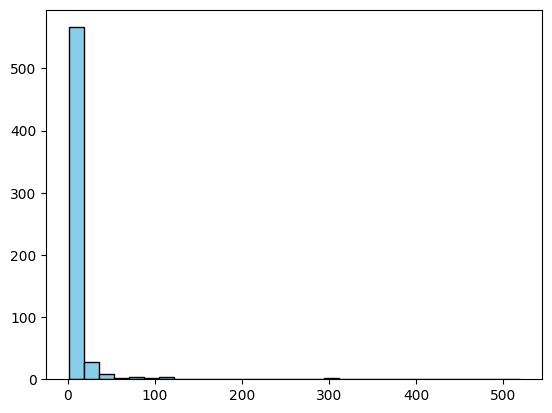

In [35]:
cluster_sizes = []
for cluster in clusters_output:
    cluster_sizes.append(len(cluster['principles']))


plt.hist(cluster_sizes, bins=30, color='skyblue', edgecolor='black')


In [36]:
import numpy as np

# use gpt 4.1 to summarize each cluster of principles into a single principle that captures the general idea of each
with open(r'C:\Users\hbbel\OneDrive\Desktop\Research\Git Repos\Principle-Elicitation\clustering\prompts\principle_summary_prompt.txt', 'r') as f:
    summary_prompt = f.read()


k = 5  # number of principles to include in the prompt

summarized_principles = []

for cluster in tqdm(clusters_output):

    # Calculate centroid of cluster embeddings

    cluster_embeddings = [embeddings[i] for i, label in enumerate(labels) if label == cluster["cluster_id"]]
    centroid = np.mean(cluster_embeddings, axis=0)

    # Find the k principles closest to the centroid
    distances = [np.linalg.norm(np.array(embedding) - centroid) for embedding in cluster_embeddings]
    closest_indices = np.argsort(distances)[:k]
    closest_principles = [cluster["principles"][i] for i in closest_indices]


    principles_text = "\n".join([f"{i+1}. {p}" for i, p in enumerate(closest_principles)])
    prompt = f"\n\nPrinciples:\n{principles_text}\n\nSummarized Principle:"
    
    summarized_principles.append(summarize_cluster(cluster, prompt, summary_prompt))

with open('12_12_FINAL_summarized_principles.json', 'w') as f:
    json.dump(summarized_principles, f, indent=4)



  0%|          | 0/622 [00:00<?, ?it/s]

100%|██████████| 622/622 [10:11<00:00,  1.02it/s]
